<a href="https://colab.research.google.com/github/anithepani/Clothing-Items-Classifier/blob/main/Wardrobe_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("agrigorev/clothing-dataset-full")
print(f"Dataset download to {path}")

100%|██████████| 6.50G/6.50G [01:01<00:00, 114MB/s]

Extracting files...


Dataset download to /root/.cache/kagglehub/datasets/agrigorev/clothing-dataset-full/versions/1


In [ ]:
def get_mean_and_std(dataloader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0

    for images, _ in dataloader:
        # Mean over batch, height and width, but keep the 3 color channels separate
        channels_sum += torch.mean(images, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(images**2, dim=[0, 2, 3])
        num_batches += 1

    mean = channels_sum / num_batches

    # Standard deviation formula: sqrt(E[X^2] - (E[X])^2)
    std = (channels_squared_sum / num_batches - mean**2)**0.5

    return mean, std

# How you would use it in code:
# 1. Create a temporary loader with ONLY ToTensor()
# 2. Run: mean, std = get_mean_and_std(your_loader)
# 3. Print them, copy them, and plug them into your final transform pipeline!

In [ ]:
# 1. Define the ResNet-50 specific transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

import pandas as pd
from torch.utils.data import Dataset

# 2. Point to the extracted Kaggle data and CSV
csv_path = f"{path}/images.csv"
data_dir = f"{path}/images_original"

# 3. Build a Custom PyTorch Dataset
class CustomClothingDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        # Load the CSV
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # We only want our 5 minimalist wardrobe classes
        self.target_classes = ['T-Shirt', 'Pants', 'Shoes', 'Shirt', 'Outwear']

        # Filter the CSV so it ONLY contains rows with our target classes
        self.annotations = self.annotations[self.annotations['label'].isin(self.target_classes)].reset_index(drop=True)

        # Add this sanity check!
        print(f"Data successfully loaded! Found {len(self.annotations)} valid images.")

        # Create a mapping of string labels to numerical indexes (e.g., 'pants' -> 1)
        self.class_to_idx = {c: i for i, c in enumerate(self.target_classes)}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self):
        # PyTorch needs to know how many total images we have
        return len(self.annotations)

    def __getitem__(self, index):
        # 1. Get the image ID from the CSV and construct the file path
        img_id = self.annotations.iloc[index]['image']
        img_path = os.path.join(self.root_dir, f"{img_id}.jpg")

        # 2. Load the image
        image = Image.open(img_path).convert("RGB")

        # 3. Get the string label and convert it to a number
        label_str = self.annotations.iloc[index]['label']
        y_label = self.class_to_idx[label_str]

        # 4. Apply our ResNet transformations (resize, crop, normalize)
        if self.transform:
            image = self.transform(image)

        return image, y_label

# 4. Instantiate the custom dataset
wardrobe_dataset = CustomClothingDataset(csv_file=csv_path, root_dir=data_dir, transform=data_transforms['train'])

# Store these mappings so the inference block can read them later
idx_to_class = wardrobe_dataset.idx_to_class
target_classes = wardrobe_dataset.target_classes

# 5. Split into 80% train, 20% validation
train_size = int(0.8 * len(wardrobe_dataset))
val_size = len(wardrobe_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(wardrobe_dataset, [train_size, val_size])

# Note: We overwrite the validation dataset's transform so it doesn't use random flips/crops during testing
val_dataset.dataset.transform = data_transforms['val']

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Data successfully loaded! Found 2824 valid images.
cuda


In [ ]:
# ==========================================
# STAGE 3: RESNET-50 MODIFICATION & TRAINING
# ==========================================

# 1. Load the pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 2. Freeze the base layers (Stop the gradients!)
for param in model.parameters():
    param.requires_grad = False

# 3. Swap the final layer
# ResNet-50's final layer is accessed via model.fc
num_ftrs = model.fc.in_features
# We replace it with a new Linear layer that outputs our 5 specific wardrobe classes
model.fc = nn.Linear(num_ftrs, len(target_classes))

# Send the model to the GPU (if available)
model = model.to(device)

# 4. Set up the Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
# Notice we ONLY pass model.fc.parameters() to the optimizer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 5. The Training Loop (Let's run just 3 epochs to see it learn quickly)
num_epochs = 3

for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Training mode
        else:
            model.eval()   # Evaluation mode

        running_loss = 0.0
        running_corrects = 0

        # Iterate over batches of data
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # Clear old gradients

            # Forward pass
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward pass and optimize ONLY in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # Tally up the loss and correct predictions
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Calculate epoch statistics
        epoch_loss = running_loss / len(dataloaders[phase].dataset)
        epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    print()

print("Training Complete!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


Epoch 1/3
----------
Train Loss: 0.7894 Acc: 0.7574
Val Loss: 0.4446 Acc: 0.8690

Epoch 2/3
----------
Train Loss: 0.3905 Acc: 0.8809
Val Loss: 0.3871 Acc: 0.8690

Epoch 3/3
----------
Train Loss: 0.3215 Acc: 0.9013
Val Loss: 0.3919 Acc: 0.8531

Training Complete!


In [ ]:
def predict_clothing(model, image_path):
    model.eval()

    # Load and transform the image
    image = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms['val'](image).unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(input_tensor)
        _, preds = torch.max(outputs, 1)

    predicted_idx = preds.item()

    # In a Subset, we have to map the index back to our specific class dictionary
    # This is a bit of PyTorch mapping logic
    predicted_class = idx_to_class[predicted_idx]

    # Display the result
    plt.imshow(image)
    plt.title(f'Network Prediction: {predicted_class}')
    plt.axis('off')
    plt.show()

# Grab a random image from the web or your dataset and test it!
# predict_clothing(model, './clothing_data/images_original/t-shirt/some_image.jpg')

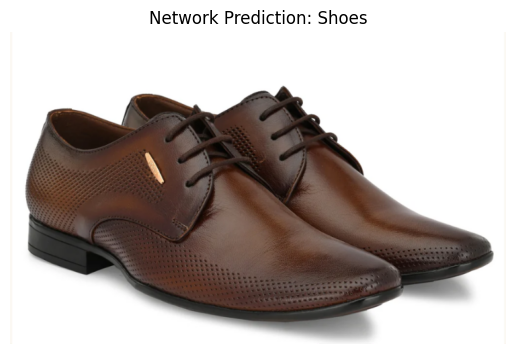

In [ ]:
img_path = "/content/Screenshot 2026-05-21 041543.png"
predict_clothing(model, img_path)